In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 12,
                     'axes.grid': True, 'grid.alpha': 0.3})

FIGURE_DIR = './figures/nb05'
os.makedirs(FIGURE_DIR, exist_ok=True)

# %%
panel = pd.read_parquet('./data/panel_ca_daily_v2.parquet')
panel['date'] = pd.to_datetime(panel['date'])
panel['community_area'] = panel['community_area'].astype(str)  # for C() in formula
print(f"Panel: {panel.shape[0]:,} x {panel.shape[1]}")

Matplotlib is building the font cache; this may take a moment.


Panel: 703,087 x 59


DID sample: 9,503 rows
  HH communities: 11
  LL communities: 2
  Pre-period rows:  5,785
  Post-period rows: 3,718

Group means (crime_total):
  LL pre:  4.01
  LL post: 3.60
  HH pre:  20.72
  HH post: 14.25
  Raw DID: -6.05

Y Variable                  DID Coef   Clust SE   t-stat    p-value   Sig
---------------------------------------------------------------------------
  Total Crime                 -6.047      1.462    -4.14     0.0000   ***
  Violent Crime               -0.920      0.296    -3.11     0.0019    **
  Property Crime              -2.628      1.088    -2.42     0.0157     *
  Theft                       -2.722      1.132    -2.40     0.0162     *
  Battery                     -0.647      0.165    -3.93     0.0001   ***
  Homicide                    +0.012      0.013     0.89     0.3761      
  Burglary                    +0.059      0.108     0.55     0.5832      
  Motor Vehicle Theft         +0.134      0.050     2.65     0.0080    **
  Narcotics                   

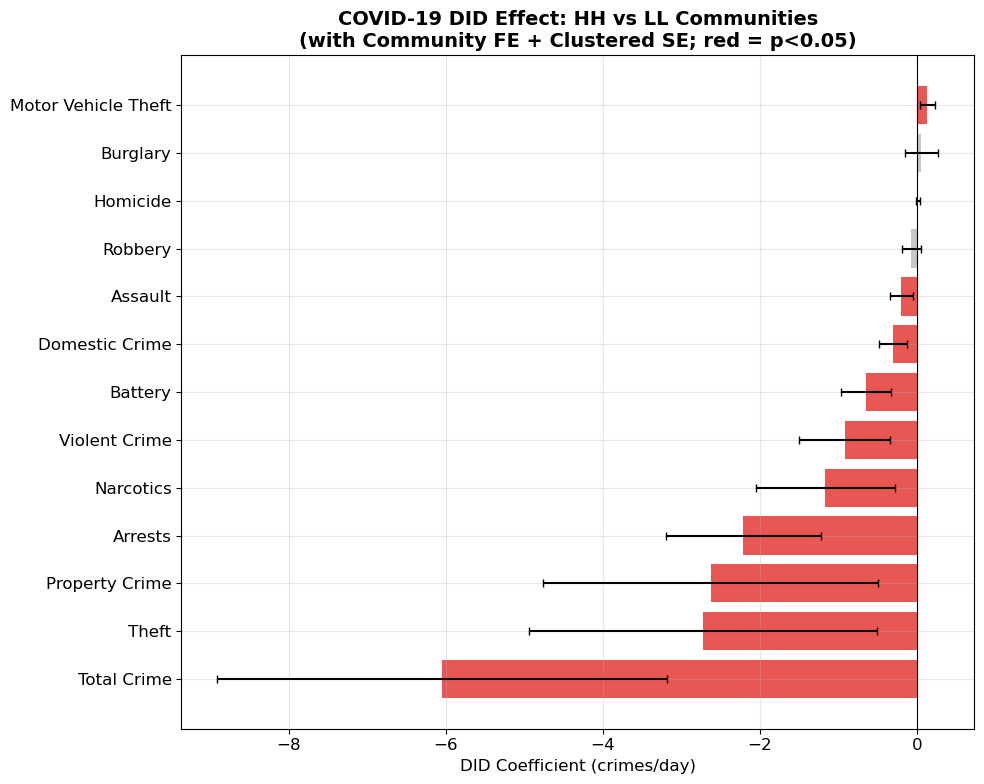

In [2]:
# Step 1: DID with Community Fixed Effects

# - C(community_area): absorbs all time-invariant community characteristics
#   (poverty, population, geography, policing history, etc.)
# - Clustered SE at community level: accounts for within-community correlation
# Model:
# Y_it = α_i + β₁·Post_t + β₃·Post_t×HH_i + X_it·γ + ε_it
# where α_i = community fixed effect (absorbs β₂·HH_i)

# 1.1 Prepare DID sample

did_sample = panel[
    (panel['lisa_cluster'].isin(['HH', 'LL'])) &
    (panel['year'].isin([2019, 2020]))
].copy()

did_sample['post'] = (did_sample['date'] >= '2020-03-21').astype(int)
did_sample['treated'] = (did_sample['lisa_cluster'] == 'HH').astype(int)
did_sample['did'] = did_sample['post'] * did_sample['treated']

n_hh = did_sample[did_sample['treated']==1]['community_area'].nunique()
n_ll = did_sample[did_sample['treated']==0]['community_area'].nunique()

print(f"DID sample: {len(did_sample):,} rows")
print(f"  HH communities: {n_hh}")
print(f"  LL communities: {n_ll}")
print(f"  Pre-period rows:  {(did_sample['post']==0).sum():,}")
print(f"  Post-period rows: {(did_sample['post']==1).sum():,}")

# Group means
means = did_sample.groupby(['treated', 'post'])['crime_total'].mean()
print(f"\nGroup means (crime_total):")
print(f"  LL pre:  {means.get((0,0), 0):.2f}")
print(f"  LL post: {means.get((0,1), 0):.2f}")
print(f"  HH pre:  {means.get((1,0), 0):.2f}")
print(f"  HH post: {means.get((1,1), 0):.2f}")
raw_did = (means.get((1,1),0) - means.get((1,0),0)) - (means.get((0,1),0) - means.get((0,0),0))
print(f"  Raw DID: {raw_did:.2f}")

# 1.2 DID regression with community FE + clustered SE

y_variables = [
    ('crime_total', 'Total Crime'),
    ('crime_violent', 'Violent Crime'),
    ('crime_property', 'Property Crime'),
    ('crime_theft', 'Theft'),
    ('crime_battery', 'Battery'),
    ('crime_homicide', 'Homicide'),
    ('crime_burglary', 'Burglary'),
    ('crime_mvt', 'Motor Vehicle Theft'),
    ('crime_narcotics', 'Narcotics'),
    ('crime_robbery', 'Robbery'),
    ('crime_assault', 'Assault'),
    ('arrest_count', 'Arrests'),
    ('domestic_count', 'Domestic Crime'),
]

# Formula with community FE
# Note: 'treated' is absorbed by C(community_area) since it doesn't vary within community
controls = 'temp_mean + precipitation + is_weekend + is_holiday'
formula_fe = '{y} ~ post + did + ' + controls + ' + C(community_area)'

did_results = []
print(f"\n{'Y Variable':<25s} {'DID Coef':>10s} {'Clust SE':>10s} {'t-stat':>8s} {'p-value':>10s} {'Sig':>5s}")
print("-" * 75)

for y_col, y_label in y_variables:
    formula = formula_fe.format(y=y_col)
    model = smf.ols(formula, data=did_sample).fit(
        cov_type='cluster',
        cov_kwds={'groups': did_sample['community_area']}
    )
    coef = model.params['did']
    se = model.bse['did']
    t = model.tvalues['did']
    p = model.pvalues['did']
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))

    did_results.append({
        'y_var': y_col, 'label': y_label,
        'coef': coef, 'se': se, 't': t, 'p': p
    })
    print(f"  {y_label:<23s} {coef:>+10.3f} {se:>10.3f} {t:>8.2f} {p:>10.4f} {sig:>5s}")

did_df = pd.DataFrame(did_results)

# 1.3 Compare: with FE vs without FE

# Run without FE for comparison
formula_no_fe = '{y} ~ post + treated + did + ' + controls

print(f"\n{'Y Variable':<20s} {'No FE':>10s} {'With FE':>10s} {'Change':>10s}")
print("-" * 55)

for y_col, y_label in y_variables[:5]:  # Show top 5 for brevity
    mod_no_fe = smf.ols(formula_no_fe.format(y=y_col), data=did_sample).fit(cov_type='HC1')
    mod_fe = smf.ols(formula_fe.format(y=y_col), data=did_sample).fit(
        cov_type='cluster', cov_kwds={'groups': did_sample['community_area']}
    )
    coef_no = mod_no_fe.params['did']
    coef_fe = mod_fe.params['did']
    change = coef_fe - coef_no
    print(f"  {y_label:<18s} {coef_no:>+10.3f} {coef_fe:>+10.3f} {change:>+10.3f}")

# 1.4 DID Coefficient Plot

fig, ax = plt.subplots(figsize=(10, 8))

plot_df = did_df.sort_values('coef')
colors = ['#E53935' if p < 0.05 else '#BDBDBD' for p in plot_df['p']]

ax.barh(range(len(plot_df)), plot_df['coef'], xerr=1.96*plot_df['se'],
        color=colors, capsize=3, alpha=0.85)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['label'])
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('DID Coefficient (crimes/day)')
ax.set_title('COVID-19 DID Effect: HH vs LL Communities\n'
             '(with Community FE + Clustered SE; red = p<0.05)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '01_did_coefficients_fe.png'), dpi=150, bbox_inches='tight')
plt.show()


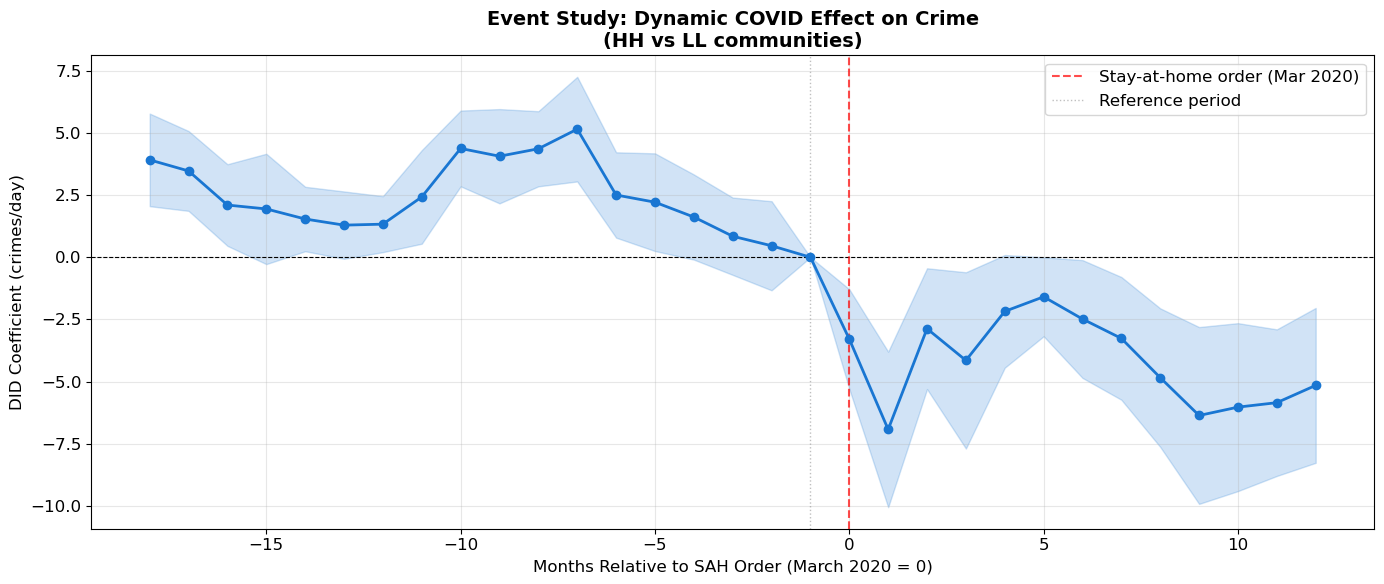

Pre-treatment months: 18
Significant at p<0.05: 12
Parallel trends QUESTIONABLE


In [3]:
# Step 2: Event Study

es_sample = panel[
    (panel['lisa_cluster'].isin(['HH', 'LL'])) &
    (panel['date'] >= '2018-09-01') &
    (panel['date'] <= '2021-03-31')
].copy()

es_sample['treated'] = (es_sample['lisa_cluster'] == 'HH').astype(int)

# Relative month: 0 = March 2020
ref_date = pd.Timestamp('2020-03-01')
es_sample['rel_month'] = ((es_sample['date'].dt.year - ref_date.year) * 12 +
                           es_sample['date'].dt.month - ref_date.month)

# Aggregate to community x month
es_monthly = (es_sample.groupby(['community_area', 'rel_month', 'treated'])
              .agg(crime_total=('crime_total', 'mean'),
                   temp_mean=('temp_mean', 'mean'),
                   precipitation=('precipitation', 'mean'))
              .reset_index())

unique_months = sorted(es_monthly['rel_month'].unique())
ref_month = -1

def get_rm_name(m):
    return f"rm_m{abs(m)}" if m < 0 else f"rm_{m}"

for m in unique_months:
    if m != ref_month:
        col_name = get_rm_name(m)
        es_monthly[col_name] = ((es_monthly['rel_month'] == m) &
                                (es_monthly['treated'] == 1)).astype(int)

rm_terms = ' + '.join([get_rm_name(m) for m in unique_months if m != ref_month])
es_formula = f'crime_total ~ treated + C(rel_month) + {rm_terms} + temp_mean + precipitation'

es_model = smf.ols(es_formula, data=es_monthly).fit(
    cov_type='cluster',
    cov_kwds={'groups': es_monthly['community_area']}
)

es_coefs = []
for m in unique_months:
    if m == ref_month:
        es_coefs.append({'rel_month': m, 'coef': 0, 'se': 0, 'p': 1})
    else:
        key = get_rm_name(m)
        if key in es_model.params:
            es_coefs.append({
                'rel_month': m,
                'coef': es_model.params[key],
                'se': es_model.bse[key],
                'p': es_model.pvalues[key]
            })

es_df = pd.DataFrame(es_coefs)

#
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(es_df['rel_month'], es_df['coef'], 'o-', color='#1976D2', lw=2, ms=6, zorder=3)
ax.fill_between(es_df['rel_month'],
                es_df['coef'] - 1.96 * es_df['se'],
                es_df['coef'] + 1.96 * es_df['se'],
                alpha=0.2, color='#1976D2')

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(0, color='red', lw=1.5, ls='--', alpha=0.7, label='Stay-at-home order (Mar 2020)')
ax.axvline(-1, color='gray', lw=1, ls=':', alpha=0.5, label='Reference period')

ax.set_xlabel('Months Relative to SAH Order (March 2020 = 0)')
ax.set_ylabel('DID Coefficient (crimes/day)')
ax.set_title('Event Study: Dynamic COVID Effect on Crime\n(HH vs LL communities)',
             fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '02_event_study.png'), dpi=150, bbox_inches='tight')
plt.show()

pre_coefs = es_df[es_df['rel_month'] < 0]
n_sig_pre = (pre_coefs['p'] < 0.05).sum()
print(f"Pre-treatment months: {len(pre_coefs)}")
print(f"Significant at p<0.05: {n_sig_pre}")
print(f"Parallel trends {'SUPPORTED' if n_sig_pre <= 1 else 'QUESTIONABLE'}")


In [4]:
# Step 3: Heterogeneity Analysis

# 3.1 By Poverty Level

poverty_median = panel.groupby('community_area')['poverty_rate'].first().median()

het_sample = panel[panel['year'].isin([2019, 2020])].copy()
het_sample['post'] = (het_sample['date'] >= '2020-03-21').astype(int)
het_sample['high_poverty'] = (het_sample['poverty_rate'] > poverty_median).astype(int)
het_sample['did_poverty'] = het_sample['post'] * het_sample['high_poverty']

mod_pov = smf.ols(
    'crime_total ~ post + did_poverty + temp_mean + precipitation + is_weekend + C(community_area)',
    data=het_sample
).fit(cov_type='cluster', cov_kwds={'groups': het_sample['community_area']})

print("DID by Poverty Level (with FE + Clustered SE):")
print(f"  DID coefficient (high vs low poverty): {mod_pov.params['did_poverty']:+.3f}")
print(f"  Clustered SE: {mod_pov.bse['did_poverty']:.3f}")
print(f"  p-value: {mod_pov.pvalues['did_poverty']:.4f}")

# 3.2 By COVID Phase

phase_sample = panel[
    (panel['lisa_cluster'].isin(['HH', 'LL'])) &
    (panel['year'].isin([2019, 2020]))
].copy()

phase_sample['treated'] = (phase_sample['lisa_cluster'] == 'HH').astype(int)

phases = {
    'Strict Lockdown': ('2020-03-21', '2020-06-02'),
    'Partial Reopen': ('2020-06-03', '2020-12-31'),
}

print(f"\n{'Phase':<25s} {'DID Coef':>10s} {'Clust SE':>10s} {'p-value':>10s} {'Sig':>5s}")
print("-" * 65)

for phase_name, (start, end) in phases.items():
    ps = phase_sample.copy()
    ps['post'] = ((ps['date'] >= start) & (ps['date'] <= end)).astype(int)
    ps['did'] = ps['post'] * ps['treated']

    mod = smf.ols(
        'crime_total ~ post + did + temp_mean + precipitation + is_weekend + C(community_area)',
        data=ps
    ).fit(cov_type='cluster', cov_kwds={'groups': ps['community_area']})

    sig = '***' if mod.pvalues['did'] < 0.001 else ('**' if mod.pvalues['did'] < 0.01 else ('*' if mod.pvalues['did'] < 0.05 else ''))
    print(f"  {phase_name:<23s} {mod.params['did']:>+10.3f} {mod.bse['did']:>10.3f} {mod.pvalues['did']:>10.4f} {sig:>5s}")


DID by Poverty Level (with FE + Clustered SE):
  DID coefficient (high vs low poverty): -0.222
  Clustered SE: 0.632
  p-value: 0.7254

Phase                       DID Coef   Clust SE    p-value   Sig
-----------------------------------------------------------------
  Strict Lockdown             -5.268      1.177     0.0000   ***
  Partial Reopen              -4.667      1.214     0.0001   ***


In [5]:
# Step 4: Robustness Checks

# 4.1 Placebo Test (with FE)

placebo = panel[
    (panel['lisa_cluster'].isin(['HH', 'LL'])) &
    (panel['year'].isin([2018, 2019]))
].copy()

placebo['post'] = (placebo['date'] >= '2019-03-21').astype(int)
placebo['treated'] = (placebo['lisa_cluster'] == 'HH').astype(int)
placebo['did'] = placebo['post'] * placebo['treated']

mod_placebo = smf.ols(
    'crime_total ~ post + did + temp_mean + precipitation + is_weekend + C(community_area)',
    data=placebo
).fit(cov_type='cluster', cov_kwds={'groups': placebo['community_area']})

print("Placebo Test (fake COVID March 2019, 2018-2019 window):")
print(f"  DID coefficient: {mod_placebo.params['did']:+.3f}")
print(f"  Clustered SE: {mod_placebo.bse['did']:.3f}")
print(f"  p-value: {mod_placebo.pvalues['did']:.4f}")
print(f"  Result: {'PASS (not significant)' if mod_placebo.pvalues['did'] > 0.05 else 'FAIL (significant)'}")

# 4.2 Alternative Time Windows

windows = {
    '2019 vs 2020 (baseline)': ([2019], [2020]),
    '2018-2019 vs 2020': ([2018, 2019], [2020]),
    '2019 vs 2020-2021': ([2019], [2020, 2021]),
}

print(f"\n{'Window':<30s} {'DID Coef':>10s} {'Clust SE':>10s} {'p-value':>10s}")
print("-" * 65)

for label, (pre_years, post_years) in windows.items():
    ws = panel[
        (panel['lisa_cluster'].isin(['HH', 'LL'])) &
        (panel['year'].isin(pre_years + post_years))
    ].copy()
    ws['post'] = ws['year'].isin(post_years).astype(int)
    ws['treated'] = (ws['lisa_cluster'] == 'HH').astype(int)
    ws['did'] = ws['post'] * ws['treated']

    mod = smf.ols(
        'crime_total ~ post + did + temp_mean + precipitation + is_weekend + C(community_area)',
        data=ws
    ).fit(cov_type='cluster', cov_kwds={'groups': ws['community_area']})
    print(f"  {label:<28s} {mod.params['did']:>+10.3f} {mod.bse['did']:>10.3f} {mod.pvalues['did']:>10.4f}")

# 4.3 Alternative Grouping (Median Split — all 77 communities)

ca_median_crime = panel[panel['year'] == 2019].groupby('community_area')['crime_total'].mean()
median_val = ca_median_crime.median()

alt_sample = panel[panel['year'].isin([2019, 2020])].copy()
alt_sample['high_crime'] = (alt_sample['community_area'].map(ca_median_crime) > median_val).astype(int)
alt_sample['post'] = (alt_sample['date'] >= '2020-03-21').astype(int)
alt_sample['did'] = alt_sample['post'] * alt_sample['high_crime']

mod_alt = smf.ols(
    'crime_total ~ post + did + temp_mean + precipitation + is_weekend + C(community_area)',
    data=alt_sample
).fit(cov_type='cluster', cov_kwds={'groups': alt_sample['community_area']})

print("Alternative grouping (median split, all 77 communities, with FE):")
print(f"  DID coefficient: {mod_alt.params['did']:+.3f}")
print(f"  Clustered SE: {mod_alt.bse['did']:.3f}")
print(f"  p-value: {mod_alt.pvalues['did']:.4f}")
print(f"  N communities: {alt_sample['community_area'].nunique()}")

# 4.4 Additional Controls (COVID severity + Unemployment)

robust_sample = panel[
    (panel['lisa_cluster'].isin(['HH', 'LL'])) &
    (panel['year'].isin([2019, 2020]))
].copy()

robust_sample['post'] = (robust_sample['date'] >= '2020-03-21').astype(int)
robust_sample['treated'] = (robust_sample['lisa_cluster'] == 'HH').astype(int)
robust_sample['did'] = robust_sample['post'] * robust_sample['treated']

# Baseline (same as Step 1)
mod_base = smf.ols(
    'crime_total ~ post + did + temp_mean + precipitation + is_weekend + C(community_area)',
    data=robust_sample
).fit(cov_type='cluster', cov_kwds={'groups': robust_sample['community_area']})

# With COVID cases
mod_covid = smf.ols(
    'crime_total ~ post + did + temp_mean + precipitation + is_weekend + covid_cases_7d + C(community_area)',
    data=robust_sample
).fit(cov_type='cluster', cov_kwds={'groups': robust_sample['community_area']})

print(f"\n{'Specification':<35s} {'DID Coef':>10s} {'Clust SE':>10s} {'p-value':>10s}")
print("-" * 70)
print(f"  {'Baseline (with FE)':<33s} {mod_base.params['did']:>+10.3f} {mod_base.bse['did']:>10.3f} {mod_base.pvalues['did']:>10.4f}")
print(f"  {'+ COVID cases control':<33s} {mod_covid.params['did']:>+10.3f} {mod_covid.bse['did']:>10.3f} {mod_covid.pvalues['did']:>10.4f}")

# With unemployment (if available)
if 'unemployment_monthly' in robust_sample.columns:
    rs_unemp = robust_sample.dropna(subset=['unemployment_monthly'])
    if len(rs_unemp) > 100:
        mod_unemp = smf.ols(
            'crime_total ~ post + did + temp_mean + precipitation + is_weekend + unemployment_monthly + C(community_area)',
            data=rs_unemp
        ).fit(cov_type='cluster', cov_kwds={'groups': rs_unemp['community_area']})
        print(f"  {'+ Unemployment control':<33s} {mod_unemp.params['did']:>+10.3f} {mod_unemp.bse['did']:>10.3f} {mod_unemp.pvalues['did']:>10.4f}")


Placebo Test (fake COVID March 2019, 2018-2019 window):
  DID coefficient: +0.415
  Clustered SE: 0.325
  p-value: 0.2021
  Result: PASS (not significant)

Window                           DID Coef   Clust SE    p-value
-----------------------------------------------------------------
  2019 vs 2020 (baseline)          -5.776      1.345     0.0000
  2018-2019 vs 2020                -5.917      1.409     0.0000
  2019 vs 2020-2021                -5.860      1.211     0.0000
Alternative grouping (median split, all 77 communities, with FE):
  DID coefficient: -2.811
  Clustered SE: 0.557
  p-value: 0.0000
  N communities: 77

Specification                         DID Coef   Clust SE    p-value
----------------------------------------------------------------------
  Baseline (with FE)                    -6.047      1.462     0.0000
  + COVID cases control                 -6.047      1.462     0.0000
  + Unemployment control                -6.047      1.462     0.0000
